# 03 - Training - Classical ML model (XGBoost)

Section **3.4 Training - Classical ML model** of the report.

## Brief

Classical ML model: justify the choice of algorithm and describe hyperparameters and the tuning process.

- Justify the algorithm choice (XGBoost or other).
- Initial hyperparameters and tuning process (grid / random / bayes).
- Validation strategy (CV, holdout).
- Persist the trained model to `models/` and metrics to `reports/`.

In [16]:
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
import wandb
from dotenv import load_dotenv
from scipy import sparse
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor

from diplo_mod_1.constants import CONFIGS, MODELS, PROCESSED, RANDOM_STATE, REPORTS
from diplo_mod_1.schemas.evaluation import evaluate_predictor
from diplo_mod_1.training import (
    ModelRegistry,
    TuningHistory,
    XGBoostTuner,
    XGBoostTuningConfig,
    detect_xgboost_device,
)
from diplo_mod_1.training.shap_support import patch_shap_xgboost_base_score

# override=True so re-running this cell after editing .env (without a kernel
# restart) always picks up the new values, instead of keeping whatever was
# already loaded into os.environ earlier in this kernel session.
load_dotenv(override=True)
optuna.logging.set_verbosity(optuna.logging.WARNING)
patch_shap_xgboost_base_score()  # shap 0.49.1 vs XGBoost 3.x base_score format — see shap_support.py

# Experiment tracking is opt-in: set WANDB_ENABLED=true (in .env or the shell)
# to log this run to Weights & Biases. Off by default so `poe check` / nbmake
# executions don't create a W&B run on every lint/test pass.
WANDB_ENABLED = os.environ.get("WANDB_ENABLED", "false").lower() == "true"

## Step 1 — Load processed dataset

Unscaled tabular features exported by notebook 02 (`data/processed/xgboost/`).

In [2]:
xgb_dir = PROCESSED / "xgboost"
X_train = np.load(xgb_dir / "X_train.npy")
X_val = np.load(xgb_dir / "X_val.npy")
X_test = np.load(xgb_dir / "X_test.npy")
y_train = np.load(xgb_dir / "y_train.npy")
y_val = np.load(xgb_dir / "y_val.npy")
y_test = np.load(xgb_dir / "y_test.npy")

feature_meta = json.loads((xgb_dir / "feature_names.json").read_text(encoding="utf-8"))
feature_names = feature_meta["feature_names"]

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"Features: {len(feature_names)}")

X_train: (83180, 44), X_val: (20796, 44), X_test: (25995, 44)
Features: 44


## Step 2 — Baseline model

**Algorithm choice: XGBoost.** Gradient-boosted trees handle the mix of continuous, binary, and target-encoded features here without scaling, capture non-linear effects noted in EDA (e.g. the vintage-year U-shape), and are the standard strong baseline for tabular regression — a better fit than a linear model given the feature set built in notebook 02.

Untuned defaults first, to have a number the tuned model must beat.

In [3]:
tuning_config_name = os.environ.get("XGBOOST_TUNING_CONFIG", "xgboost_tuning.json")
tuning_config = XGBoostTuningConfig.from_json(CONFIGS / tuning_config_name)
print(f"Loaded tuning config: {tuning_config_name}")

# Computed once here and reused everywhere downstream (W&B run name, the
# model_filename in models/, and the run_id in reports/xgboost_metrics.json)
# so all three always point at the exact same run — no ambiguity about which
# W&B run produced which saved model.
run_id = f"{Path(tuning_config_name).stem}-{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}"

if WANDB_ENABLED:
    run_name = os.environ.get("WANDB_RUN_NAME") or f"xgboost-{run_id}"
    wandb.init(
        project=os.environ.get("WANDB_PROJECT", "diplo-mod-1"),
        name=run_name,
        group="xgboost-baseline",
        job_type="hpo",
        config={"tuning_config_name": tuning_config_name, **tuning_config.model_dump()},
    )

baseline = XGBRegressor(
    random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist", device=detect_xgboost_device()
)
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)
baseline_rmse = root_mean_squared_error(y_val, baseline_pred)
baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_r2 = r2_score(y_val, baseline_pred)
print(f"Baseline val RMSE: {baseline_rmse:.4f}")
print(f"Baseline val MAE:  {baseline_mae:.4f}")
print(f"Baseline val R2:   {baseline_r2:.4f}")

if WANDB_ENABLED:
    wandb.log(
        {
            "baseline_val_rmse": baseline_rmse,
            "baseline_val_mae": baseline_mae,
            "baseline_val_r2": baseline_r2,
        }
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Loaded tuning config: xgboost_tuning_text_probe_v2.json


wandb: Currently logged in as: leonardo-heis (leonardo-a-heis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


XGBoost device: cuda
Baseline val RMSE: 1.6979
Baseline val MAE:  1.3287
Baseline val R2:   0.6886


c:\Users\leona\source\repos\diplo-mod-1\.venv\lib\site-packages\xgboost\core.py:751: UserWarning: [10:09:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


## Step 3 — Hyperparameter tuning (Optuna)

Bayesian search (TPE sampler) via `XGBoostTuner` (`src/diplo_mod_1/training/`), configured from a JSON file in `configs/` — default `xgboost_tuning.json`, override with the `XGBOOST_TUNING_CONFIG` env var (e.g. `XGBOOST_TUNING_CONFIG=xgboost_tuning_wide.json`) to try a different search space without touching code or overwriting the default file. Search-space bounds: `max_depth` (capped at 8 by default — deeper trees were the main overfit driver in the first pass), `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_weight`, and regularization terms `reg_alpha`, `reg_lambda`, `gamma`. Each trial fits on `train` and scores RMSE against the held-out `val` split, with early stopping — `val` doubles as both the tuning objective and the early-stopping monitor, so `test` stays untouched until final evaluation.

In [4]:
def log_trial_to_wandb(study: optuna.Study, trial: optuna.trial.FrozenTrial) -> None:
    wandb.log({"trial": trial.number, "val_rmse": trial.value, **trial.params})


tuner = XGBoostTuner(tuning_config)
callbacks = [log_trial_to_wandb] if WANDB_ENABLED else None
study = tuner.tune(X_train, y_train, X_val, y_val, callbacks=callbacks)

print(f"Best val RMSE: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

if WANDB_ENABLED:
    wandb.log(
        {
            "best_val_rmse": study.best_value,
            **{f"best_{k}": v for k, v in study.best_params.items()},
        }
    )

  0%|          | 0/50 [00:00<?, ?it/s]

Best val RMSE: 1.6365
Best params: {'max_depth': 8, 'learning_rate': 0.09128035188473145, 'n_estimators': 398, 'subsample': 0.8314588717765954, 'colsample_bytree': 0.621777069078813, 'min_child_weight': 10, 'reg_alpha': 1.1146549754165801e-07, 'reg_lambda': 5.319721597496823e-06, 'gamma': 2.8815495522377273e-07}


## Step 4 — Final model

Refit with `study.best_params`, same early-stopping setup, to pick the boosting round that generalizes best rather than the fixed `n_estimators` from the search.

In [5]:
best_model = tuner.fit_best(X_train, y_train, X_val, y_val, study)
print(f"Best iteration: {best_model.best_iteration}")

Best iteration: 397


## Step 5 — Evaluate on train / val / test

In [6]:
splits = {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}
result = evaluate_predictor(best_model, splits, model_type="xgboost")

for m in result.metrics:
    print(f"{m.split:5s}  RMSE={m.rmse:.4f}  MAE={m.mae:.4f}  R2={m.r2:.4f}")
    if WANDB_ENABLED:
        wandb.log({f"{m.split}_rmse": m.rmse, f"{m.split}_mae": m.mae, f"{m.split}_r2": m.r2})

train  RMSE=1.2010  MAE=0.9279  R2=0.8437
val    RMSE=1.6365  MAE=1.2758  R2=0.7107
test   RMSE=1.6309  MAE=1.2667  R2=0.7129


## Step 6 — Feature importance

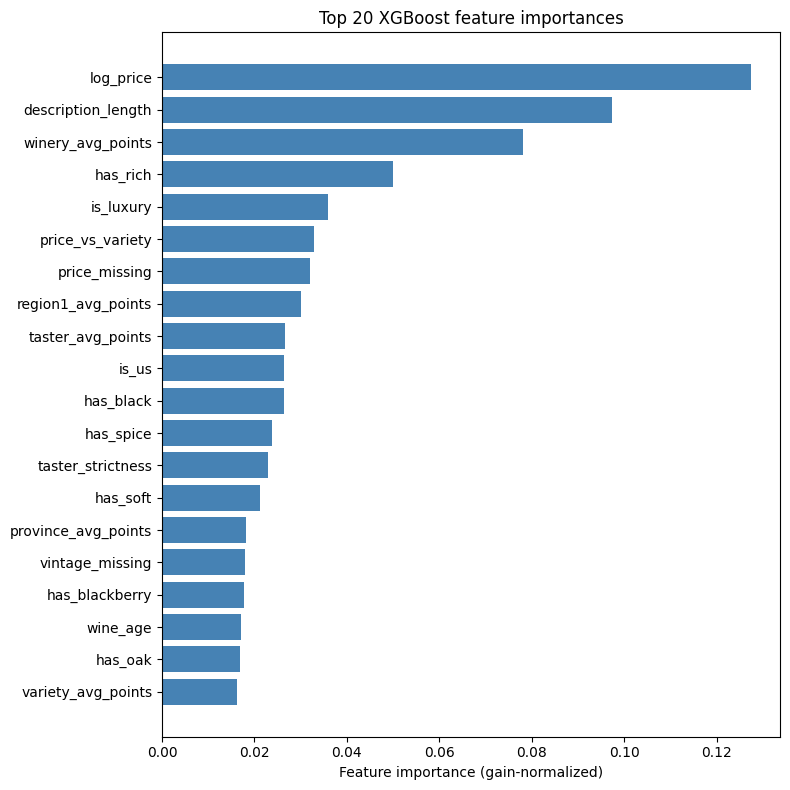

In [7]:
importances = best_model.feature_importances_
order = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh([feature_names[i] for i in order][::-1], importances[order][::-1], color="steelblue")
ax.set_xlabel("Feature importance (gain-normalized)")
ax.set_title("Top 20 XGBoost feature importances")
plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log({"feature_importance": wandb.Image(fig)})

## Step 7 — Residual analysis

Residuals (`y_test - predicted`) for `best_model` on `test`: checks for heteroscedasticity (does error grow with the predicted score?), skew in the error distribution, and whether the model systematically over/under-predicts at specific `points` ranges. Run before Step 8 persists/closes the W&B run, so the plot gets logged too when `WANDB_ENABLED=true`.

Residual mean:   -0.0023  (0 = unbiased)
Residual std:    1.6309
Residual |max|:  8.8512


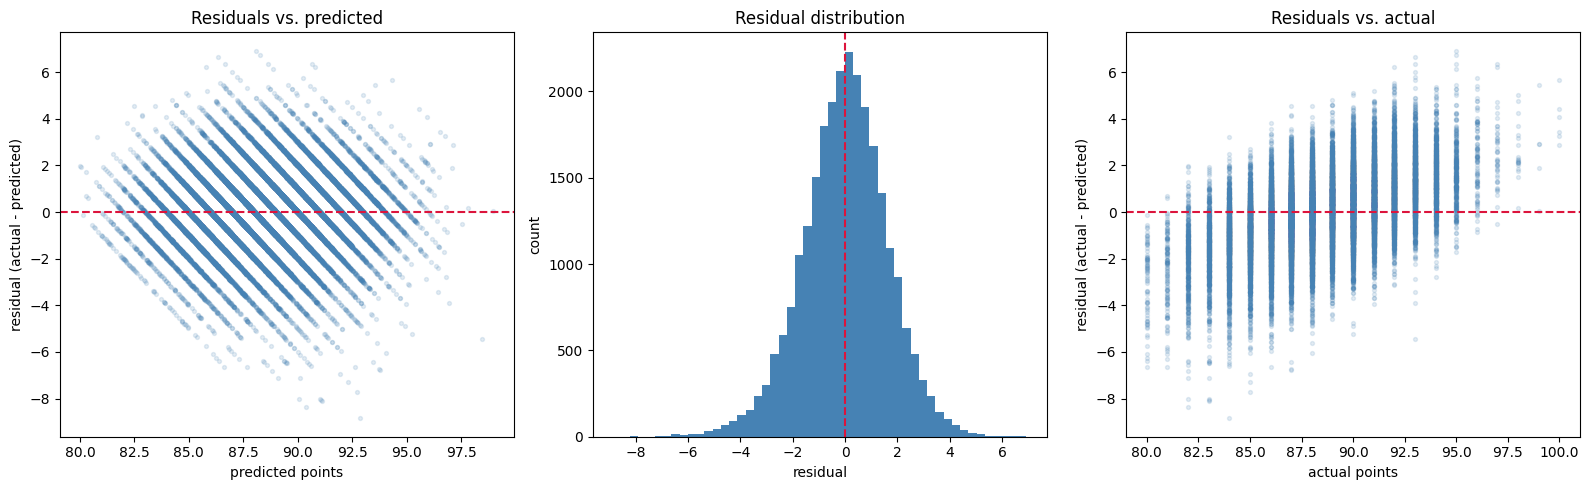

In [8]:
test_pred = best_model.predict(X_test)
residuals = y_test - test_pred

print(f"Residual mean:   {residuals.mean():.4f}  (0 = unbiased)")
print(f"Residual std:    {residuals.std():.4f}")
print(f"Residual |max|:  {np.abs(residuals).max():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(test_pred, residuals, alpha=0.15, s=8, color="steelblue")
ax.axhline(0, color="crimson", lw=1.5, linestyle="--")
ax.set_xlabel("predicted points")
ax.set_ylabel("residual (actual - predicted)")
ax.set_title("Residuals vs. predicted")

ax = axes[1]
ax.hist(residuals, bins=50, color="steelblue")
ax.axvline(0, color="crimson", lw=1.5, linestyle="--")
ax.set_xlabel("residual")
ax.set_ylabel("count")
ax.set_title("Residual distribution")

ax = axes[2]
ax.scatter(y_test, residuals, alpha=0.15, s=8, color="steelblue")
ax.axhline(0, color="crimson", lw=1.5, linestyle="--")
ax.set_xlabel("actual points")
ax.set_ylabel("residual (actual - predicted)")
ax.set_title("Residuals vs. actual")

plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log({"residual_analysis": wandb.Image(fig)})

## Step 8 — Persist model and metrics

`ModelRegistry` (`src/diplo_mod_1/training/registry.py`) versions every run instead of overwriting: each run's checkpoint is saved as `models/xgboost_<run_id>.joblib`, and `models/xgboost_best.joblib` always points at whichever run has the lowest **test**-split RMSE on record — so nothing is lost when trying a different `configs/*.json` search space, and there's an explicit pointer to the current winner. `reports/xgboost_metrics.json` holds the full `{run_id, tuning_config, best_params, metrics}` history plus `best_run_id`, consumed by notebook 05 for the model comparison. If `WANDB_ENABLED=true`, the same run also has the search-space config, every Optuna trial, baseline metrics, final train/val/test metrics, the feature-importance plot, the residual-analysis plot, and the model checkpoint itself (as a W&B artifact) logged to Weights & Biases (project from `WANDB_PROJECT`, default `diplo-mod-1`; run name from `WANDB_RUN_NAME`, default auto-generated from the tuning config).

In [9]:
run_record, history = ModelRegistry.save_run(
    MODELS,
    REPORTS / "xgboost_metrics.json",
    best_model,
    run_id,
    tuning_config_name,
    study.best_params,
    result,
)

print(f"Model saved to {MODELS / run_record.model_filename}")
print(f"Best run so far: {history.best_run_id} -> models/xgboost_best.joblib")
print(f"Metrics appended to reports/xgboost_metrics.json ({len(history.runs)} run(s) on record)")

if WANDB_ENABLED:
    artifact = wandb.Artifact("xgboost_model", type="model")
    artifact.add_file(str(MODELS / run_record.model_filename))
    wandb.log_artifact(artifact)
    wandb.finish()

Model saved to ..\models\xgboost_tuning_text_probe_v2-20260730T130905Z.joblib
Best run so far: xgboost_tuning_text_probe+text-20260730T025129Z -> models/xgboost_best.joblib
Metrics appended to reports/xgboost_metrics.json (12 run(s) on record)


baseline_val_mae,▁
baseline_val_r2,▁
baseline_val_rmse,▁
best_colsample_bytree,▁
best_gamma,▁
best_learning_rate,▁
best_max_depth,▁
best_min_child_weight,▁
best_n_estimators,▁
best_reg_alpha,▁
+22,...


## Step 9 — Compare all XGBoost runs

Every run recorded in `reports/xgboost_metrics.json` (across all `configs/*.json` search spaces tried), side by side. The winning row matches `models/xgboost_best.joblib`.

In [14]:
history_path = REPORTS / "xgboost_metrics.json"
all_runs = TuningHistory.model_validate_json(history_path.read_text(encoding="utf-8"))

comparison = pd.DataFrame(
    [
        {
            "run_id": r.run_id,
            "tuning_config": r.tuning_config,
            "train_r2": next(m.r2 for m in r.metrics if m.split == "train"),
            "train_mae": next(m.mae for m in r.metrics if m.split == "train"),
            "train_rmse": next(m.rmse for m in r.metrics if m.split == "train"),
            "test_r2": next(m.r2 for m in r.metrics if m.split == "test"),
            "test_rmse": next(m.rmse for m in r.metrics if m.split == "test"),
            "test_mae": next(m.mae for m in r.metrics if m.split == "test"),
            "val_r2": next(m.r2 for m in r.metrics if m.split == "val"),
            "val_rmse": next(m.rmse for m in r.metrics if m.split == "val"),
            "val_mae": next(m.mae for m in r.metrics if m.split == "val"),
            "is_best": r.run_id == all_runs.best_run_id,
        }
        for r in all_runs.runs
    ]
).sort_values("test_r2", ascending=False)

comparison

,run_id,tuning_config,train_r2,train_mae,train_rmse,test_r2,test_rmse,test_mae,val_r2,val_rmse,val_mae,is_best
12,xgboost_tuning_text_probe_v2+text-20260730T131...,xgboost_tuning_text_probe_v2.json+text,0.878363,0.834063,1.059455,0.774511,1.445316,1.120262,0.778034,1.433497,1.110361,True
9,xgboost_tuning_text_probe+text-20260730T025129Z,xgboost_tuning_text_probe.json+text,0.845686,0.944015,1.193311,0.767361,1.468053,1.142046,0.770240,1.458450,1.137181,False
6,xgboost_tuning_wide_v2-20260729T232250Z,xgboost_tuning_wide_v2.json,0.971873,0.371152,0.509466,0.725714,1.594050,1.225794,0.723715,1.599311,1.231879,False
10,xgboost_tuning_text_probe_v1-20260730T032948Z,xgboost_tuning_text_probe_v1.json,0.965267,0.410866,0.566139,0.725033,1.596028,1.227732,0.723470,1.600020,1.234820,False
2,xgboost_tuning_wide_v2-20260729T030927Z,xgboost_tuning_wide_v2.json,0.959789,0.444780,0.609151,0.720736,1.608452,1.239931,0.718843,1.613349,1.248701,False
5,xgboost_tuning-20260729T231642Z,xgboost_tuning.json,0.874711,0.821507,1.075244,0.720262,1.609817,1.248352,0.718030,1.615680,1.256642,False
4,xgboost_tuning_wide-20260729T230841Z,xgboost_tuning_wide.json,0.918731,0.647142,0.865989,0.718330,1.615364,1.248630,0.715996,1.621498,1.257332,False
1,xgboost_tuning_wide-20260729T030243Z,xgboost_tuning_wide.json,0.895892,0.741621,0.980150,0.714954,1.625016,1.259570,0.713466,1.628704,1.264333,False
11,xgboost_tuning_text_probe_v2-20260730T130905Z,xgboost_tuning_text_probe_v2.json,0.843691,0.927857,1.200997,0.712883,1.630909,1.266651,0.710717,1.636496,1.275849,False
0,xgboost_tuning-20260729T025351Z,xgboost_tuning.json,0.841297,0.933759,1.210162,0.711803,1.633974,1.271129,0.708276,1.643389,1.282545,False


## Step 10 — Add TF-IDF text features (experiment)

XGBoost so far only sees `description` via `description_length` + keyword flags. The NN dataset (notebook 02) already has the full TF-IDF matrix (2000 terms, fit on train) — stack it onto the tabular columns to see whether that untapped text signal moves test RMSE past the plateau hyperparameter tuning alone couldn't break.

In [11]:
nn_dir = PROCESSED / "nn"
X_txt = {
    split: sparse.load_npz(nn_dir / f"X_txt_{split}.npz") for split in ("train", "val", "test")
}

tfidf_vectorizer = joblib.load(nn_dir / "tfidf_vectorizer.joblib")
text_feature_names = list(tfidf_vectorizer.get_feature_names_out())

tabular = {"train": X_train, "val": X_val, "test": X_test}
X_combined = {
    split: sparse.hstack([sparse.csr_matrix(tabular[split]), X_txt[split]], format="csr")
    for split in ("train", "val", "test")
}
combined_feature_names = feature_names + text_feature_names

print(
    f"Combined feature count: {len(combined_feature_names)} "
    f"({len(feature_names)} tabular + {len(text_feature_names)} TF-IDF)"
)
print(f"X_combined train shape: {X_combined['train'].shape}")

Combined feature count: 2044 (44 tabular + 2000 TF-IDF)
X_combined train shape: (83180, 2044)


## Step 11 — Retune XGBoost on tabular + TF-IDF features

Same `XGBoostTuner`, same `tuning_config` (from Step 2/`XGBOOST_TUNING_CONFIG`) — only the input matrix changes. XGBoost's sklearn API accepts the sparse `X_combined` directly. Own W&B run (`group="xgboost-text"`), separate from Step 8's already-closed tabular-only run.

In [12]:
text_run_id = (
    f"{Path(tuning_config_name).stem}+text-{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}"
)

if WANDB_ENABLED:
    wandb.init(
        project=os.environ.get("WANDB_PROJECT", "diplo-mod-1"),
        name=f"xgboost-{text_run_id}",
        group="xgboost-text",
        job_type="hpo",
        config={
            "tuning_config_name": tuning_config_name,
            "features": "tabular+tfidf",
            **tuning_config.model_dump(),
        },
    )


def log_text_trial_to_wandb(study: optuna.Study, trial: optuna.trial.FrozenTrial) -> None:
    wandb.log({"trial": trial.number, "val_rmse": trial.value, **trial.params})


text_tuner = XGBoostTuner(tuning_config)
text_callbacks = [log_text_trial_to_wandb] if WANDB_ENABLED else None
text_study = text_tuner.tune(
    X_combined["train"], y_train, X_combined["val"], y_val, callbacks=text_callbacks
)

print(f"Best val RMSE (tabular+text): {text_study.best_value:.4f}")
print(f"Best params: {text_study.best_params}")

if WANDB_ENABLED:
    wandb.log(
        {
            "best_val_rmse": text_study.best_value,
            **{f"best_{k}": v for k, v in text_study.best_params.items()},
        }
    )

  0%|          | 0/50 [00:00<?, ?it/s]

Best val RMSE (tabular+text): 1.4335
Best params: {'max_depth': 7, 'learning_rate': 0.1376745040972406, 'n_estimators': 486, 'subsample': 0.9713386595732587, 'colsample_bytree': 0.8781008449058327, 'min_child_weight': 5, 'reg_alpha': 0.0006842761454463577, 'reg_lambda': 2.489962422261251e-08, 'gamma': 0.0003476681165664887}


## Step 12 — Refit, evaluate, and persist the text-augmented model

Same flow as Steps 4-8 (refit best params, evaluate, feature importance, `ModelRegistry`), applied to the combined tabular+TF-IDF model. Tagged `"<tuning_config>+text"` in `reports/xgboost_metrics.json` so Step 9's comparison table shows it distinctly from the tabular-only runs.

Best iteration: 485
train  RMSE=1.0595  MAE=0.8341  R2=0.8784
val    RMSE=1.4335  MAE=1.1104  R2=0.7780
test   RMSE=1.4453  MAE=1.1203  R2=0.7745


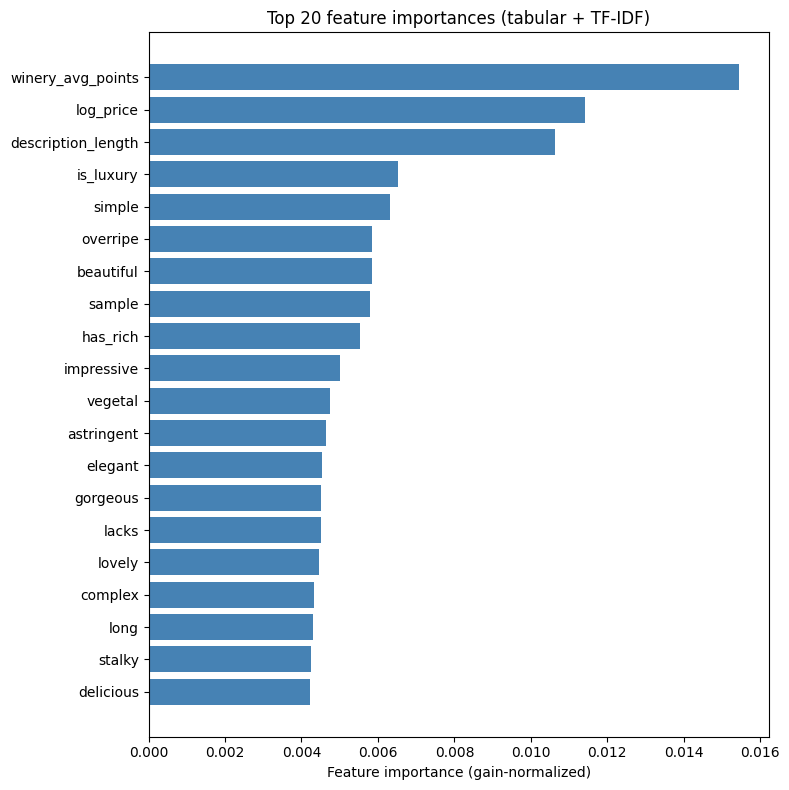

Model saved to ..\models\xgboost_tuning_text_probe_v2+text-20260730T131147Z.joblib
Best run so far: xgboost_tuning_text_probe_v2+text-20260730T131147Z -> models/xgboost_best.joblib
Metrics appended to reports/xgboost_metrics.json (13 run(s) on record)


best_colsample_bytree,▁
best_gamma,▁
best_learning_rate,▁
best_max_depth,▁
best_min_child_weight,▁
best_n_estimators,▁
best_reg_alpha,▁
best_reg_lambda,▁
best_subsample,▁
best_val_rmse,▁
+19,...


In [13]:
text_best_model = text_tuner.fit_best(
    X_combined["train"], y_train, X_combined["val"], y_val, text_study
)
print(f"Best iteration: {text_best_model.best_iteration}")

text_splits = {
    "train": (X_combined["train"], y_train),
    "val": (X_combined["val"], y_val),
    "test": (X_combined["test"], y_test),
}
text_result = evaluate_predictor(text_best_model, text_splits, model_type="xgboost")

for m in text_result.metrics:
    print(f"{m.split:5s}  RMSE={m.rmse:.4f}  MAE={m.mae:.4f}  R2={m.r2:.4f}")
    if WANDB_ENABLED:
        wandb.log({f"{m.split}_rmse": m.rmse, f"{m.split}_mae": m.mae, f"{m.split}_r2": m.r2})

text_importances = text_best_model.feature_importances_
text_order = np.argsort(text_importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(
    [combined_feature_names[i] for i in text_order][::-1],
    text_importances[text_order][::-1],
    color="steelblue",
)
ax.set_xlabel("Feature importance (gain-normalized)")
ax.set_title("Top 20 feature importances (tabular + TF-IDF)")
plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log({"feature_importance": wandb.Image(fig)})

text_run_record, text_history = ModelRegistry.save_run(
    MODELS,
    REPORTS / "xgboost_metrics.json",
    text_best_model,
    text_run_id,
    f"{tuning_config_name}+text",
    text_study.best_params,
    text_result,
)

print(f"Model saved to {MODELS / text_run_record.model_filename}")
print(f"Best run so far: {text_history.best_run_id} -> models/xgboost_best.joblib")
print(
    f"Metrics appended to reports/xgboost_metrics.json ({len(text_history.runs)} run(s) on record)"
)

if WANDB_ENABLED:
    artifact = wandb.Artifact("xgboost_model_text", type="model")
    artifact.add_file(str(MODELS / text_run_record.model_filename))
    wandb.log_artifact(artifact)
    wandb.finish()

## Step 13 — SHAP explainability on the overall-best model

Loads `models/xgboost_best.joblib` **fresh from disk** rather than trusting whichever `best_model`/`text_best_model` happens to be in kernel memory — that variable is only "whatever ran last," not necessarily the actual best across every run in `reports/xgboost_metrics.json`. Feature count on the loaded model decides whether to explain it against the tabular-only or tabular+TF-IDF test set, so this cell doesn't need to know in advance which one won. `shap.TreeExplainer` is exact and fast for tree models (unlike the slow model-agnostic explainers), run on a sample of `test` for speed. Own W&B run (`group="xgboost-shap"`, `job_type="explainability"`), tagged with the run it's explaining.

Explaining xgboost_tuning_text_probe_v2+text-20260730T131147Z (2044 features) on 1000 sampled test rows
      feature  mean_abs_shap
     gorgeous       0.866972
        lacks       0.837284
    dominates       0.712159
      generic       0.610335
         lean       0.608014
      perfect       0.546665
       grainy       0.532644
       medium       0.516394
  light color       0.507251
        focus       0.463062
  meyer lemon       0.448430
barrel sample       0.411503
         pipe       0.398651
        grape       0.395492
 blackberries       0.376093


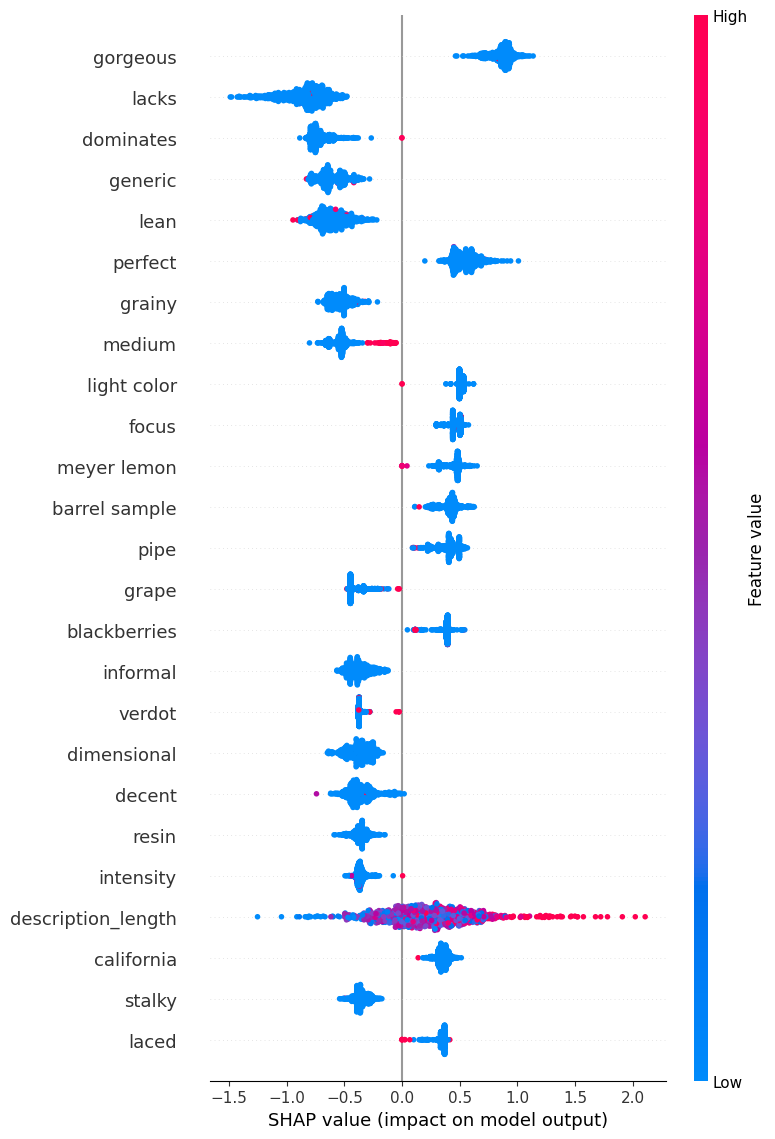

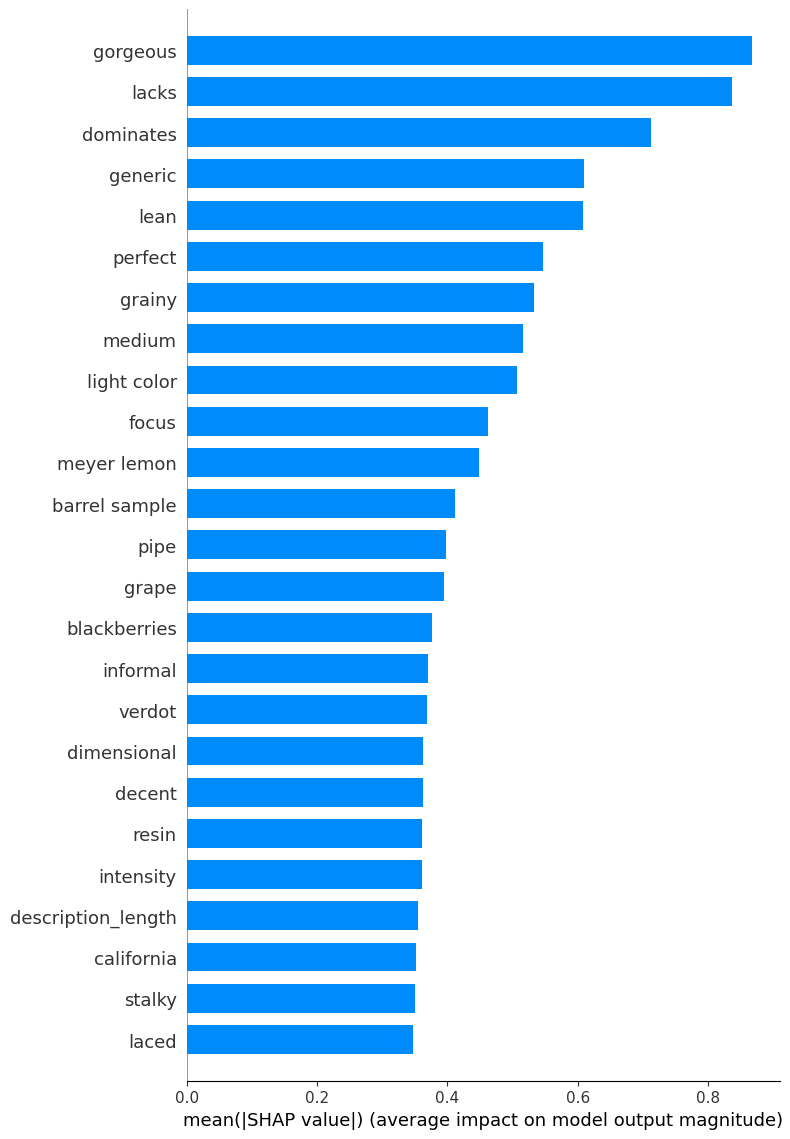

In [17]:
SHAP_SAMPLE_SIZE = 1000

overall_history = TuningHistory.model_validate_json(
    (REPORTS / "xgboost_metrics.json").read_text(encoding="utf-8")
)
best_overall = joblib.load(MODELS / "xgboost_best.joblib")
n_features = best_overall.n_features_in_

if n_features == len(feature_names):
    X_test_full, explain_names = X_test, feature_names
elif n_features == len(combined_feature_names):
    X_test_full, explain_names = X_combined["test"], combined_feature_names
else:
    raise RuntimeError(
        f"xgboost_best.joblib expects {n_features} features, but neither the "
        f"tabular ({len(feature_names)}) nor tabular+TF-IDF ({len(combined_feature_names)}) "
        "test set matches. Re-run Steps 1 and 10 in this kernel session first."
    )

rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(SHAP_SAMPLE_SIZE, X_test_full.shape[0])
sample_idx = rng.choice(X_test_full.shape[0], size=sample_size, replace=False)

X_sample = X_test_full[sample_idx]
if sparse.issparse(X_sample):
    X_sample = X_sample.toarray()

print(
    f"Explaining {overall_history.best_run_id} ({n_features} features) "
    f"on {sample_size} sampled test rows"
)

explainer = shap.TreeExplainer(best_overall)
shap_values = explainer.shap_values(X_sample)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:30]
shap_table = pd.DataFrame(
    {"feature": [explain_names[i] for i in top_idx], "mean_abs_shap": mean_abs_shap[top_idx]}
)
print(shap_table.head(15).to_string(index=False))

shap.summary_plot(shap_values, X_sample, feature_names=explain_names, max_display=25, show=False)
beeswarm_fig = plt.gcf()
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=explain_names,
    plot_type="bar",
    max_display=25,
    show=False,
)
bar_fig = plt.gcf()
plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.init(
        project=os.environ.get("WANDB_PROJECT", "diplo-mod-1"),
        name=f"shap-{overall_history.best_run_id}",
        group="xgboost-shap",
        job_type="explainability",
        config={
            "explained_run_id": overall_history.best_run_id,
            "n_features": n_features,
            "sample_size": sample_size,
        },
    )
    wandb.log(
        {
            "shap_summary_beeswarm": wandb.Image(beeswarm_fig),
            "shap_summary_bar": wandb.Image(bar_fig),
            "shap_top_features": wandb.Table(dataframe=shap_table),
        }
    )
    wandb.finish()

## Step 14 — Design notes (report)

**Algorithm choice:** XGBoost — handles the mixed continuous/binary/target-encoded feature matrix from notebook 02 without scaling, and captures non-linear relationships (e.g. the vintage-year U-shape found in EDA) that a linear baseline cannot.

**Feature set:** notebook 02's tabular export grew from 40 to 44 columns — added `province_avg_points` (target-encoded), `region1_freq` (frequency-encoded), `price_vs_variety` (log-price relative to that grape variety's average), and `taster_strictness` (previously NN-only, now shared with XGBoost). Re-tuning every existing search config on the enriched set gave small, consistent gains (~0.5-1.5% lower test RMSE across the board) — a real signal, not noise, since it held across every independently-tuned config.

**Tuning process:** Bayesian optimization via Optuna (TPE sampler), configured from `configs/*.json` (selectable via `XGBOOST_TUNING_CONFIG`) and run through the reusable `XGBoostTuner` class (`src/diplo_mod_1/training/`) rather than inline in the notebook — mirrors the `DataCleaner`/`FeatureEngineer`/`TabularEncoder` pattern from notebook 02. Each trial uses early stopping against `val` rather than a fixed boosting-round count. GPU-accelerated: `detect_device()` auto-probes XGBoost's own CUDA capability (not `torch.cuda.is_available()` — this project's torch build is CPU-only, independent of XGBoost's bundled CUDA runtime) and falls back to CPU, so the same code runs unmodified on the NVIDIA/Windows and Apple Silicon/Mac machines used for this project (XGBoost has no MPS backend, unlike the PyTorch NN in notebook 04).

**Hyperparameter tuning alone plateaued.** Roughly ten separate Optuna searches — varying depth, regularization, learning rate — all converged to test R² in the 0.71-0.73 band, within noise of each other. That plateau motivated the next step.

**Feature experiment — TF-IDF text (Steps 10-12): this is what broke the plateau.** XGBoost previously only saw `description` via a character count and ~25 hand-picked keyword flags. Stacking the same TF-IDF matrix already built for the NN dataset (2000 terms, fit on train) onto the 44 tabular columns — 2044 features total — and re-running the identical Optuna flow dropped test RMSE from 1.594 to **1.445** (≈9% relative improvement) and raised R² from 0.726 to **0.775**. This is now `models/xgboost_best.joblib`. Step 13's SHAP analysis independently confirms it: the top features by mean |SHAP| are almost entirely TF-IDF terms ("gorgeous", "lacks", "dominates", "generic"...), not tabular columns — the review text is now the dominant signal, not a marginal add-on.

**Validation strategy:** holdout, not k-fold CV — reuses the stratified `train`/`val`/`test` split from notebook 02. `val` drives both the Optuna objective and early stopping; `test` is touched only once, for the final reported metrics (via `evaluate_predictor`, shared with notebook 04 through the `WineScorePredictor` protocol), keeping it a fair held-out estimate for the notebook 05 comparison against the neural network.

**Explainability (Step 13):** `shap.TreeExplainer` on a 1000-row sample of `test`, run against `models/xgboost_best.joblib` loaded fresh from disk (not whichever model happens to be in kernel memory) — auto-detects whether the winning model is the tabular-only or tabular+TF-IDF one by feature count. Required a scoped compatibility shim (`src/diplo_mod_1/training/shap_support.py`): shap 0.49.1 (the newest release compatible with this project's Python 3.10) can't parse XGBoost 3.x's `base_score` serialization format — patched rather than downgrading XGBoost or bumping the Python floor.

**Persistence:** every run's model checkpoint is versioned (`models/xgboost_<run_id>.joblib`, via `ModelRegistry`), with `models/xgboost_best.joblib` always pointing at the run with the lowest test RMSE recorded so far — currently a tabular+TF-IDF run. `reports/xgboost_metrics.json` accumulates the full run history (`ModelMetrics`/`EvaluationResult`, existing domain schemas) rather than overwriting, so multiple search-space and feature-set experiments stay comparable side by side (Step 9). Optionally the full run (config, trials, metrics, plots, model artifact) also goes to Weights & Biases when `WANDB_ENABLED=true`, including a dedicated run for the SHAP analysis.

**Known open question:** `ModelRegistry.best_run()`'s "lowest test RMSE wins" selection is naive — it doesn't account for overfit gap or statistical significance between close results. Not an issue for the TF-IDF result (a clear, large, consistent margin), but worth revisiting before trusting it to break ties between closely-matched configs.